# Loading the dataset

In [107]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load from excel
db_main = pd.read_excel(
    'C:/Users/sigzu/OneDrive/Dokumenter/Andre Dokumenter/Billettkontroll data/Billettkontroll data.xlsx')
db_aanerud = pd.read_excel(
    'C:/Users/sigzu/OneDrive/Dokumenter/Andre Dokumenter/Billettkontroll data/Billettkontroll data-aanerud.xlsx')


In [108]:
db_main.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 242 entries, 0 to 241
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Linje          242 non-null    object        
 1   Vogn           212 non-null    object        
 2   Dato           242 non-null    datetime64[ns]
 3   Klokke         242 non-null    object        
 4   Fra            242 non-null    object        
 5   Til            242 non-null    object        
 6   Fullt?         242 non-null    object        
 7   Sjekket?       242 non-null    object        
 8   Sjekket etter  19 non-null     object        
 9   Merknad        78 non-null     object        
dtypes: datetime64[ns](1), object(9)
memory usage: 19.0+ KB


In [109]:
db_aanerud.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44 entries, 0 to 43
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   Linje     44 non-null     object        
 1   Vogn      43 non-null     object        
 2   Dato      44 non-null     datetime64[ns]
 3   Klokke    44 non-null     object        
 4   Fra       44 non-null     object        
 5   Til       44 non-null     object        
 6   Fullt?    44 non-null     object        
 7   Sjekket?  44 non-null     object        
 8   Merknad   14 non-null     object        
dtypes: datetime64[ns](1), object(8)
memory usage: 3.2+ KB


In [110]:
db = pd.concat([db_main, db_aanerud], ignore_index=True)
db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286 entries, 0 to 285
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Linje          286 non-null    object        
 1   Vogn           255 non-null    object        
 2   Dato           286 non-null    datetime64[ns]
 3   Klokke         286 non-null    object        
 4   Fra            286 non-null    object        
 5   Til            286 non-null    object        
 6   Fullt?         286 non-null    object        
 7   Sjekket?       286 non-null    object        
 8   Sjekket etter  19 non-null     object        
 9   Merknad        92 non-null     object        
dtypes: datetime64[ns](1), object(9)
memory usage: 22.5+ KB


# Cleaning and engineering the features

In [111]:
# Convert all column names to lowercase
db.columns = db.columns.str.lower()

# Replace space with underscore in column names
db.columns = db.columns.str.replace(' ', '_')

# Remove special characters from column names
db.columns = db.columns.str.replace(r'[?]', '', regex=True)

In [112]:
# Date convert to discrete features
db['day'] = db['dato'].dt.day
db['month'] = db['dato'].dt.month
db['year'] = db['dato'].dt.year
db['weekday'] = db['dato'].dt.weekday
db['weekofyear'] = db['dato'].dt.isocalendar().week

# Remove the original date column
db = db.drop(columns=['dato'])

In [113]:
# Convert "klokke" to datetime
db['klokke'] = pd.to_datetime(db['klokke'], format='%H:%M:%S', errors='coerce')

# Convert departure time to discrete features
db['hour'] = db['klokke'].dt.hour
db['minute'] = db['klokke'].dt.minute
db['second'] = db['klokke'].dt.second

# Remove the original time column
db = db.drop(columns=['klokke'])

In [114]:
# lower all string values in the dataframe
for col in db.select_dtypes(include=['object']).columns:
    db[col] = db[col].str.lower()

# Spaces become non if end of string
for col in db.select_dtypes(include=['object']).columns:
    db[col] = db[col].str.strip()

# ja/nei -> ja and nei/ja -> ja in "sjekket" column
db['sjekket'] = db['sjekket'].replace({'ja/nei': 'ja', 'nei/ja': 'ja'})

In [115]:

db.head()

,linje,vogn,fra,til,fullt,sjekket,sjekket_etter,merknad,day,month,year,weekday,weekofyear,hour,minute,second
0,l12,fremst,eidsvoll,oslo lufthavn,nei,nei,NaN,NaN,25,9,2022,6,38,11,30,0
1,r10,bakerst,oslo lufthavn,eidsvoll,ja,ja,NaN,NaN,25,9,2022,6,38,21,59,0
2,l12,fremst,eidsvoll,nationaltheatret,ja,nei,NaN,NaN,26,9,2022,0,39,9,30,0
3,l12,bakerst,nationaltheatret,eidsvoll,ja,nei,NaN,NaN,26,9,2022,0,39,13,48,0
4,r11,fremst,eidsvoll,oslo lufthavn,nei,ja,NaN,sjekket med en gang,27,9,2022,1,39,6,0,0


### Convert "sjekket etter" to something useful

In [116]:
# TODO implement
# Remove for now
db = db.drop(columns=['sjekket_etter'])

In [117]:
# Converting all strings to numumeric values
for col in db.select_dtypes(include=['object']).columns:
    print(pd.Categorical(db[col]).categories)
    db[col] = pd.Categorical(db[col]).codes

Index(['l1', 'l12', 'l14', 'l2', 'r10', 'r11', 'r12', 'r13', 'r14', 'r21',
       'r22', 'r23', 're10', 're11'],
      dtype='object')
Index(['bakerst', 'fremst', 'midten'], dtype='object')
Index(['eidsvoll', 'lillestrøm', 'lysaker', 'lørenskog', 'nationaltheatret',
       'oslo lufthavn', 'oslo s', 'skarnes', 'ski', 'skøyen'],
      dtype='object')
Index(['eidsvoll', 'hamar', 'jessheim', 'kongsvinger', 'lillestrøm', 'lysaker',
       'nationaltheatret', 'oslo lufthavn', 'oslo s', 'skarnes', 'ski',
       'skøyen', 'årnes'],
      dtype='object')
Index(['ja', 'nei', 'noe'], dtype='object')
Index(['ja', 'nei'], dtype='object')
Index(['12 min forsinket', '15 min forsinket', '20 min forsinket',
       '3 min forsinket inn til oslo s', '5 vogner', '7 min forsinket',
       'annerledes avgangstid', 'ble sjekket med en gang toget reiste',
       'ble sjekket på seterstøa, nettsiden sa det var liten sannsynlighet',
       'ble sjekket rett før seterstøa. nettsiden sa liten sannsynlighet',
   

In [118]:
db = db.fillna(-1)

In [119]:
db.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 286 entries, 0 to 285
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   linje       286 non-null    int8  
 1   vogn        286 non-null    int8  
 2   fra         286 non-null    int8  
 3   til         286 non-null    int8  
 4   fullt       286 non-null    int8  
 5   sjekket     286 non-null    int8  
 6   merknad     286 non-null    int8  
 7   day         286 non-null    int32 
 8   month       286 non-null    int32 
 9   year        286 non-null    int32 
 10  weekday     286 non-null    int32 
 11  weekofyear  286 non-null    UInt32
 12  hour        286 non-null    int32 
 13  minute      286 non-null    int32 
 14  second      286 non-null    int32 
dtypes: UInt32(1), int32(7), int8(7)
memory usage: 11.3 KB


# Creating test and train datasets

In [120]:
# Drop irrelevant columns
db = db.drop(columns=['vogn'])
db = db.drop(columns=['merknad'])

In [121]:
x = db.drop(columns=['sjekket'], axis=1)
y = db['sjekket']
x.head()

,linje,fra,til,fullt,day,month,year,weekday,weekofyear,hour,minute,second
0,1,0,7,1,25,9,2022,6,38,11,30,0
1,4,5,0,0,25,9,2022,6,38,21,59,0
2,1,0,6,0,26,9,2022,0,39,9,30,0
3,1,4,0,0,26,9,2022,0,39,13,48,0
4,5,0,7,1,27,9,2022,1,39,6,0,0


In [122]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Create models and test

In [123]:
import xgboost as xgb

model = xgb.XGBClassifier()
model.fit(x_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


# Test model

In [124]:
preds = model.predict(x_test)
print(preds)

[1 1 1 1 1 0 1 0 1 1 1 1 0 1 1 1 1 0 1 1 1 1 1 1 0 1 1 0 0 0 1 0 1 0 1 1 1
 0 0 0 1 1 1 0 1 1 1 1 1 0 1 0 0 1 1 1 1 0]


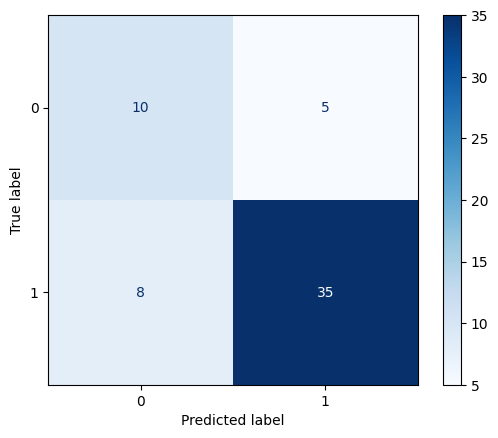

In [126]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, preds)
disp = ConfusionMatrixDisplay(cm, display_labels=model.classes_)
disp.plot(cmap="Blues")

# Save the best model